<a href="https://colab.research.google.com/github/tommihab/Haberstock-et-al.-2026-Supplementary-Material/blob/main/Haberstock_Ems_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This is the data pre processing notebook for the bachelor's thesis of Tommi Haberstock

In [ ]:
# import packages

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
# Determine the path of data

REPO_URL = "https://github.com/tommihab/Haberstock-et-al.-2026-Supplementary-Material.git"
REPO_DIR = Path("/content/Ems-Discharge-Forecasting")

if REPO_DIR.exists():
    !rm -rf "{REPO_DIR}"

!git clone "{REPO_URL}" "{REPO_DIR}"

base_dir = REPO_DIR / "Input_Data_Stations"

# Determine Precipitation data
files_rain = [
    "augustdorf_2007-2024.csv",
    "bielefeld-mitte_2007-2024.csv",
    "delbrueck-steinhorst_2007-2024.csv",
    "rheda-wiedenbrueck_2007-2024.csv",
    "rietberg_2007-2024.csv",
    "Versmold-Vorbruch_2007-2025.csv",
    "warendorf-freckenhorst_2007-2024.csv",
]
# Determine discharge data
file_q = "Einen_Stunden_2007-2024.csv"

# load .csv data (semicolon separated)
def load_csv(fp: Path) -> pd.DataFrame:
    df = pd.read_csv(fp, sep=";", parse_dates=["MESS_DATUM"])
    df = df.sort_values("MESS_DATUM").reset_index(drop=True)
    return df

rain_dfs = {fn: load_csv(base_dir / fn) for fn in files_rain}
q_df = load_csv(base_dir / file_q)

# Sanity-Check
print("Rain files loaded:", {k: v.shape for k, v in rain_dfs.items()})
print("Q file loaded:", q_df.shape)
print("Q columns:", q_df.columns.tolist())

Cloning into '/content/Ems-Discharge-Forecasting'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 48 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 15.65 MiB | 7.81 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Rain files loaded: {'augustdorf_2007-2024.csv': (149040, 2), 'bielefeld-mitte_2007-2024.csv': (149040, 2), 'delbrueck-steinhorst_2007-2024.csv': (149040, 2), 'rheda-wiedenbrueck_2007-2024.csv': (149040, 2), 'rietberg_2007-2024.csv': (149040, 2), 'Versmold-Vorbruch_2007-2025.csv': (149040, 2), 'warendorf-freckenhorst_2007-2024.csv': (149040, 2)}
Q file loaded: (149040, 2)
Q columns: ['MESS_DATUM', 'ABFLUSS']


In [ ]:
# Overview of missing values of each precipitation station

missing_summary = []

for fn, df in rain_dfs.items():
    n = len(df)
    n_missing = df["Niederschlag"].isna().sum()
    pct_missing = (n_missing / n) * 100

    tmin = df["MESS_DATUM"].min()
    tmax = df["MESS_DATUM"].max()

    missing_summary.append({
        "file": fn,
        "number_of_rows": n,
        "missing_values": int(n_missing),
        "missing_values_%": pct_missing,
        "start": tmin,
        "end": tmax
    })

missing_summary_df = pd.DataFrame(missing_summary).sort_values("missing_values", ascending=False)
missing_summary_df

,file,number_of_rows,missing_values,missing_values_%,start,end
5,Versmold-Vorbruch_2007-2025.csv,149040,581,0.389828,01.01.2007 00:00,31.12.2023 23:00
4,rietberg_2007-2024.csv,149040,22,0.014761,01.01.2007 00:00,31.12.2023 23:00
1,bielefeld-mitte_2007-2024.csv,149040,11,0.007381,01.01.2007 00:00,31.12.2023 23:00
0,augustdorf_2007-2024.csv,149040,9,0.006039,01.01.2007 00:00,31.12.2023 23:00
3,rheda-wiedenbrueck_2007-2024.csv,149040,5,0.003355,01.01.2007 00:00,31.12.2023 23:00
6,warendorf-freckenhorst_2007-2024.csv,149040,5,0.003355,01.01.2007 00:00,31.12.2023 23:00
2,delbrueck-steinhorst_2007-2024.csv,149040,4,0.002684,01.01.2007 00:00,31.12.2023 23:00


In [ ]:
# Coordinations of precipitation stations

station_coords = {
    "warendorf-freckenhorst_2007-2024.csv": (7.95043, 51.92282),
    "augustdorf_2007-2024.csv":             (8.71009, 51.90183),
    "delbrueck-steinhorst_2007-2024.csv":   (8.53361, 51.81837),
    "rietberg_2007-2024.csv":               (8.40783, 51.81261),
    "rheda-wiedenbrueck_2007-2024.csv":     (8.29750, 51.87141),
    "bielefeld-mitte_2007-2024.csv":        (8.54244, 52.03551),
    "Versmold-Vorbruch_2007-2025.csv":      (8.16004, 52.01090),
}


In [ ]:
# Haversine distance in Kilometer

def haversine_km(lon1, lat1, lon2, lat2):
    """
    Calculates the great-circle distance between two points
    on Earth (in km).
    """
    R = 6371.0  # Earth radius in km

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [ ]:
# Distance matrix between all precipitation stations

stations = list(station_coords.keys())

distance_matrix = pd.DataFrame(
    index=stations,
    columns=stations,
    dtype=float
)

for s1 in stations:
    lon1, lat1 = station_coords[s1]
    for s2 in stations:
        lon2, lat2 = station_coords[s2]
        distance_matrix.loc[s1, s2] = haversine_km(lon1, lat1, lon2, lat2)

distance_matrix


,warendorf-freckenhorst_2007-2024.csv,augustdorf_2007-2024.csv,delbrueck-steinhorst_2007-2024.csv,rietberg_2007-2024.csv,rheda-wiedenbrueck_2007-2024.csv,bielefeld-mitte_2007-2024.csv,Versmold-Vorbruch_2007-2025.csv
warendorf-freckenhorst_2007-2024.csv,0.000000,52.158937,41.689260,33.711573,24.490915,42.438859,17.382122
augustdorf_2007-2024.csv,52.158937,0.000000,15.264366,23.007031,28.518024,18.784603,39.595277
delbrueck-steinhorst_2007-2024.csv,41.689260,15.264366,0.000000,8.669838,17.258653,24.152457,33.389197
rietberg_2007-2024.csv,33.711573,23.007031,8.669838,0.000000,10.009989,26.448456,27.839513
rheda-wiedenbrueck_2007-2024.csv,24.490915,28.518024,17.258653,10.009989,0.000000,24.793394,18.148398
bielefeld-mitte_2007-2024.csv,42.438859,18.784603,24.152457,26.448456,24.793394,0.000000,26.307613
Versmold-Vorbruch_2007-2025.csv,17.382122,39.595277,33.389197,27.839513,18.148398,26.307613,0.000000


In [ ]:
# Combining all precipitation stations
# Index = time, columns = stations

rain_merged = []

for fn, df in rain_dfs.items():
    tmp = df[["MESS_DATUM", "Niederschlag"]].copy()
    tmp = tmp.rename(columns={"Niederschlag": fn})
    rain_merged.append(tmp)

rain_all = rain_merged[0]
for df in rain_merged[1:]:
    rain_all = rain_all.merge(df, on="MESS_DATUM", how="outer")

rain_all = rain_all.sort_values("MESS_DATUM").set_index("MESS_DATUM")

rain_all.head()


,augustdorf_2007-2024.csv,bielefeld-mitte_2007-2024.csv,delbrueck-steinhorst_2007-2024.csv,rheda-wiedenbrueck_2007-2024.csv,rietberg_2007-2024.csv,Versmold-Vorbruch_2007-2025.csv,warendorf-freckenhorst_2007-2024.csv
MESS_DATUM,,,,,,,
01.01.2007 00:00,0.24,0.2,0.25,0.5,0.00,0.00,0.00
01.01.2007 01:00,0.03,0.0,0.00,0.0,0.00,0.03,0.00
01.01.2007 02:00,0.00,0.0,0.00,0.0,0.00,0.13,0.00
01.01.2007 03:00,0.03,0.2,0.46,0.4,1.97,0.00,1.37
01.01.2007 04:00,1.90,0.0,1.79,0.7,0.00,0.00,0.00


In [ ]:
print("Shape:", rain_all.shape)
print("Missing values total:", rain_all.isna().sum().sum())


Shape: (149040, 7)
Missing values total: 637


In [ ]:
# IDW-function (k=4, p=2, min 2 stations)

def idw_estimate(
    target_station,
    timestamp,
    data,
    distance_matrix,
    k=4,
    p=2,
    min_stations=2
):
    """
    IDW estimation for a target station at a given point in time.
    """
    values = data.loc[timestamp]

    # Available neighbouring stations (not missing, not destination station)
    available = values.drop(labels=target_station).dropna()

    if len(available) < min_stations:
        return np.nan

    # Distances to the destination station
    distances = distance_matrix.loc[target_station, available.index]

    # Select the next stops
    nearest = distances.nsmallest(k)

    # associated precipitation values
    vals = available.loc[nearest.index]

    # IDW weights
    weights = 1 / (nearest ** p)

    return np.sum(weights * vals) / np.sum(weights)

In [ ]:
# Apply IDW interpolation

rain_idw = rain_all.copy()

filled_count = 0

for station in rain_idw.columns:
    missing_times = rain_idw.index[rain_idw[station].isna()]

    for t in missing_times:
        est = idw_estimate(
            target_station=station,
            timestamp=t,
            data=rain_idw,
            distance_matrix=distance_matrix,
            k=4,
            p=2,
            min_stations=2
        )

        if not np.isnan(est):
            rain_idw.at[t, station] = est
            filled_count += 1

print("Values filled in by IDW:", filled_count)
print("Remaining missing values:", rain_idw.isna().sum().sum())


Values filled in by IDW: 637
Remaining missing values: 0


In [ ]:
# Comparison before / after
pd.DataFrame({
    "before": rain_all.isna().sum(),
    "after": rain_idw.isna().sum()
}).sort_values("before", ascending=False)

,before,after
Versmold-Vorbruch_2007-2025.csv,581,0
rietberg_2007-2024.csv,22,0
bielefeld-mitte_2007-2024.csv,11,0
augustdorf_2007-2024.csv,9,0
rheda-wiedenbrueck_2007-2024.csv,5,0
warendorf-freckenhorst_2007-2024.csv,5,0
delbrueck-steinhorst_2007-2024.csv,4,0


In [ ]:
# Preparing discharge data

q = q_df.copy()
q = q.sort_values("MESS_DATUM").set_index("MESS_DATUM")

q = q.rename(columns={"ABFLUSS": "discharge"})
q.head()

,discharge
MESS_DATUM,
01.01.2007 00:00,14.45
01.01.2007 01:00,14.47
01.01.2007 02:00,14.50
01.01.2007 03:00,14.52
01.01.2007 04:00,14.55


In [ ]:
# Number of missing values
q.isna().sum().to_frame(name='missing values')

,missing values
discharge,0


In [ ]:
# Merge of all precipitation stations with discharge station

data = rain_idw.merge(q, left_index=True, right_index=True, how="inner")

print("Shape after merge:", data.shape)
data.head()


Shape after merge: (149040, 8)


,augustdorf_2007-2024.csv,bielefeld-mitte_2007-2024.csv,delbrueck-steinhorst_2007-2024.csv,rheda-wiedenbrueck_2007-2024.csv,rietberg_2007-2024.csv,Versmold-Vorbruch_2007-2025.csv,warendorf-freckenhorst_2007-2024.csv,discharge
MESS_DATUM,,,,,,,,
01.01.2007 00:00,0.24,0.2,0.25,0.5,0.00,0.00,0.00,14.45
01.01.2007 01:00,0.03,0.0,0.00,0.0,0.00,0.03,0.00,14.47
01.01.2007 02:00,0.00,0.0,0.00,0.0,0.00,0.13,0.00,14.50
01.01.2007 03:00,0.03,0.2,0.46,0.4,1.97,0.00,1.37,14.52
01.01.2007 04:00,1.90,0.0,1.79,0.7,0.00,0.00,0.00,14.55


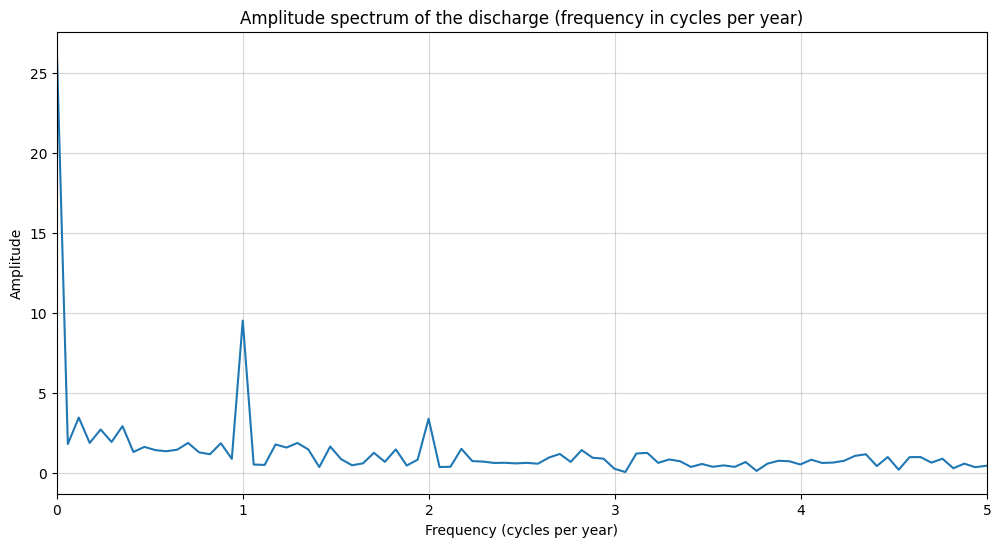

In [ ]:
# Fourier transformation

# Ensure the index is a DatetimeIndex before resampling
data.index = pd.to_datetime(data.index, format='%d.%m.%Y %H:%M')

# Resample the discharge data to hourly means, then drop any resulting NaNs.
q_hour = data["discharge"].resample("h").mean().dropna()

# daily aggregation
q_day = q_hour.resample("D").mean().dropna()

# Extracting the values for the FFT
signal = q_day.values
N = len(signal) # Number of data points

# The sampling interval is 1 day, as the data is daily.
dt = 1 # day

# Performing the Fast Fourier Transform (FFT)
yf = np.fft.fft(signal)
xf = np.fft.fftfreq(N, d=dt)

# Plot to focus on annual patterns (lower frequencies)
plt.figure(figsize=(12, 6))
plt.plot(xf[:N//2] * 365, 2.0/N * np.abs(yf[0:N//2])) # Convert frequency into cycles per year
plt.title('Amplitude spectrum of the discharge (frequency in cycles per year)')
plt.xlabel('Frequency (cycles per year)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.5)
plt.xlim(0, 5) # Focus on frequencies up to 5 cycles per year
plt.show()

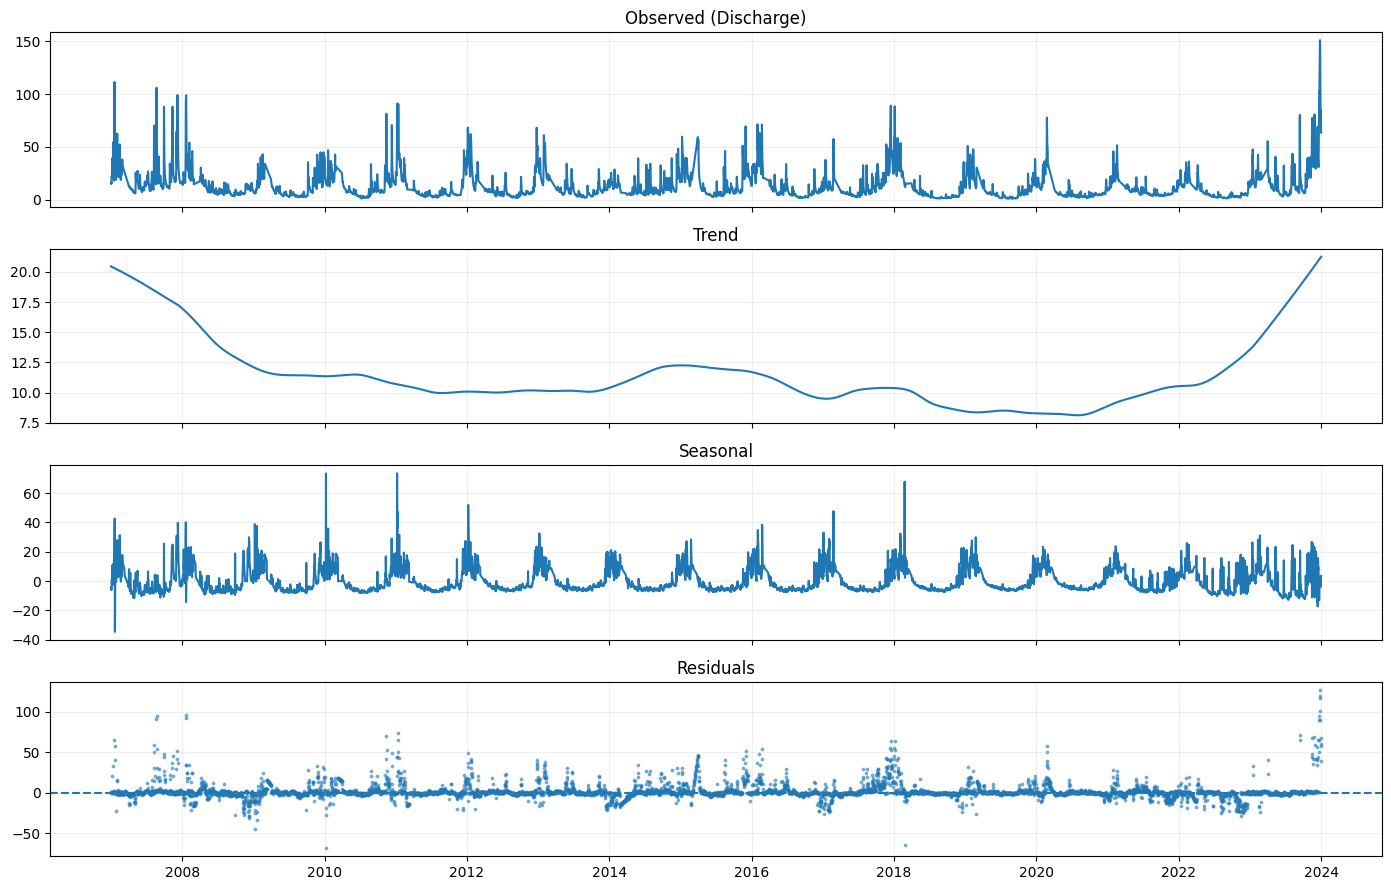

In [ ]:
from statsmodels.tsa.seasonal import STL

# perform STL decomposition of discharge data

res = STL(q_day, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

axes[0].plot(q_day.index, q_day.values)
axes[0].set_title("Observed (Discharge)")

axes[1].plot(res.trend.index, res.trend.values)
axes[1].set_title("Trend")

axes[2].plot(res.seasonal.index, res.seasonal.values)
axes[2].set_title("Seasonal")

axes[3].scatter(res.resid.index, res.resid.values, s=3, alpha=0.5)
axes[3].axhline(0, linestyle="--")
axes[3].set_title("Residuals")

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# Data extraction and alignment
obs = pd.Series(res.observed).dropna()

# Reindex trend, seasonal, and residual components to match the cleaned observed index
trend = pd.Series(res.trend).reindex(obs.index)
seasonal = pd.Series(res.seasonal).reindex(obs.index)
resid = pd.Series(res.resid).reindex(obs.index)

# Variance calculation
var_obs = np.var(obs.values, ddof=0)   # Total variance of original data
var_tr  = np.var(trend.values, ddof=0)  # Variance contributed by the trend
var_se  = np.var(seasonal.values, ddof=0)  # Variance contributed by seasonality
var_re  = np.var(resid.values, ddof=0)  # Variance contributed by random noise (residuals)

# Calculating the variance shares
# Determine what percentage of the total movement is explained by each part
var_share = pd.Series({
    "Trend": var_tr / var_obs,
    "Seasonal": var_se / var_obs,
    "Residual": var_re / var_obs,
})

var_share

,0
Trend,0.050811
Seasonal,0.401708
Residual,0.622400


In [ ]:
# Cyclical seasonality from DOY

# correctly parsing mixed date formats
data.index = pd.to_datetime(
    data.index,
    format="mixed",
    dayfirst=True,
    errors="raise"
)


In [ ]:
doy = data.index.dayofyear.astype(float)

data["DOY_sin"] = np.sin(2 * np.pi * doy / 365.25)
data["DOY_cos"] = np.cos(2 * np.pi * doy / 365.25)

data[["DOY_sin", "DOY_cos"]].head()


,DOY_sin,DOY_cos
MESS_DATUM,,
2007-01-01 00:00:00,0.017202,0.999852
2007-01-01 01:00:00,0.017202,0.999852
2007-01-01 02:00:00,0.017202,0.999852
2007-01-01 03:00:00,0.017202,0.999852
2007-01-01 04:00:00,0.017202,0.999852


In [ ]:
# Sort index
data = data.sort_index()
print("Monoton steigend nach sort:", data.index.is_monotonic_increasing)
# Check index quality
print("Anzahl doppelter Zeitstempel:", data.index.duplicated().sum())

Monoton steigend nach sort: True
Anzahl doppelter Zeitstempel: 0


In [ ]:
# Check year transition
data.loc["2007-12-31 20:00:00":"2008-01-01 04:00:00", ["DOY_sin", "DOY_cos"]]

,DOY_sin,DOY_cos
MESS_DATUM,,
2007-12-31 20:00:00,-0.004301,0.999991
2007-12-31 21:00:00,-0.004301,0.999991
2007-12-31 22:00:00,-0.004301,0.999991
2007-12-31 23:00:00,-0.004301,0.999991
2008-01-01 00:00:00,0.017202,0.999852
2008-01-01 01:00:00,0.017202,0.999852
2008-01-01 02:00:00,0.017202,0.999852
2008-01-01 03:00:00,0.017202,0.999852
2008-01-01 04:00:00,0.017202,0.999852


In [ ]:
data.loc["2008-12-31 20:00:00":"2009-01-01 04:00:00", ["DOY_sin", "DOY_cos"]]

,DOY_sin,DOY_cos
MESS_DATUM,,
2008-12-31 20:00:00,0.012901,0.999917
2008-12-31 21:00:00,0.012901,0.999917
2008-12-31 22:00:00,0.012901,0.999917
2008-12-31 23:00:00,0.012901,0.999917
2009-01-01 00:00:00,0.017202,0.999852
2009-01-01 01:00:00,0.017202,0.999852
2009-01-01 02:00:00,0.017202,0.999852
2009-01-01 03:00:00,0.017202,0.999852
2009-01-01 04:00:00,0.017202,0.999852


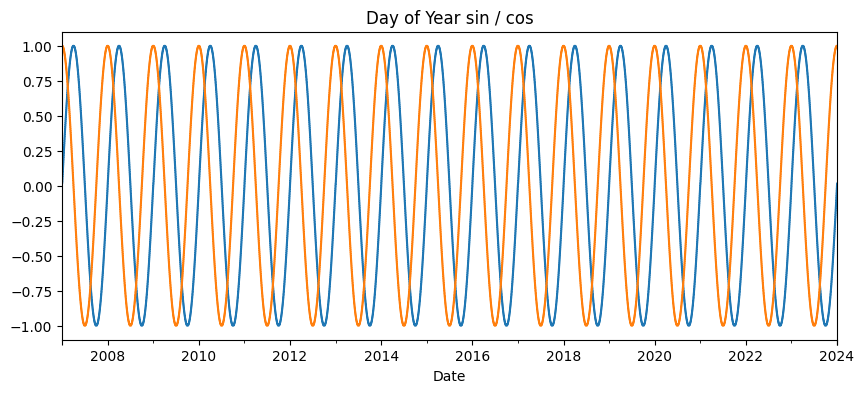

In [ ]:
# Visualise DOY

ax = data[["DOY_sin", "DOY_cos"]].plot(
    figsize=(10, 4),
    title="Day of Year sin / cos",
    legend=False
)
ax.set_xlabel("Date")
plt.show()

In [ ]:
# Overview: Structure & first lines

print("Spalten:")
display(pd.DataFrame({
    "Spalte": data.columns,
    "Typ": data.dtypes.values
}))

print("\nBeispieldaten:")
display(data.head(10))

Spalten:


,Spalte,Typ
0,augustdorf_2007-2024.csv,float64
1,bielefeld-mitte_2007-2024.csv,float64
2,delbrueck-steinhorst_2007-2024.csv,float64
3,rheda-wiedenbrueck_2007-2024.csv,float64
4,rietberg_2007-2024.csv,float64
5,Versmold-Vorbruch_2007-2025.csv,float64
6,warendorf-freckenhorst_2007-2024.csv,float64
7,discharge,float64
8,DOY_sin,float64
9,DOY_cos,float64



Beispieldaten:


,augustdorf_2007-2024.csv,bielefeld-mitte_2007-2024.csv,delbrueck-steinhorst_2007-2024.csv,rheda-wiedenbrueck_2007-2024.csv,rietberg_2007-2024.csv,Versmold-Vorbruch_2007-2025.csv,warendorf-freckenhorst_2007-2024.csv,discharge,DOY_sin,DOY_cos
MESS_DATUM,,,,,,,,,,
2007-01-01 00:00:00,0.24,0.2,0.25,0.5,0.00,0.00,0.00,14.45,0.017202,0.999852
2007-01-01 01:00:00,0.03,0.0,0.00,0.0,0.00,0.03,0.00,14.47,0.017202,0.999852
2007-01-01 02:00:00,0.00,0.0,0.00,0.0,0.00,0.13,0.00,14.50,0.017202,0.999852
2007-01-01 03:00:00,0.03,0.2,0.46,0.4,1.97,0.00,1.37,14.52,0.017202,0.999852
2007-01-01 04:00:00,1.90,0.0,1.79,0.7,0.00,0.00,0.00,14.55,0.017202,0.999852
2007-01-01 05:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,14.57,0.017202,0.999852
2007-01-01 06:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,14.60,0.017202,0.999852
2007-01-01 07:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.03,14.63,0.017202,0.999852
2007-01-01 08:00:00,0.00,0.0,0.00,0.0,0.00,1.22,0.39,14.65,0.017202,0.999852


In [ ]:
# Preparations for corss correlation of precipitation and discharge
# Give stations weights caculated from Thiessen polygons that were clipped with the catchment area

weights = {
    'rietberg_2007-2024.csv': 0.092482164,
    'Versmold-Vorbruch_2007-2025.csv': 0.239524497,
    'bielefeld-mitte_2007-2024.csv': 0.092138528,
    'warendorf-freckenhorst_2007-2024.csv': 0.110527554,
    'rheda-wiedenbrueck_2007-2024.csv': 0.243288684,
    'delbrueck-steinhorst_2007-2024.csv': 0.124391312,
    'augustdorf_2007-2024.csv': 0.097647261,
}

# 'data' is the DataFrame containing all precipitation stations and runoff.
missing = [c for c in weights.keys() if c not in data.columns]
print("Missing columns:", missing)


# Standardise weights for safety reasons
w = pd.Series(weights)
w = w / w.sum()

# Apply weighted rainfall to the “data” DataFrame
data["P_weighted"] = sum(data[c] * w[c] for c in w.index)

Missing columns: []


In [ ]:
# Basic configuration
max_lag = 336  # Maximum time offset
threshold = 0.1 # Minimum correlation to be considered significant

def crosscorr_rain_to_flow(df, rain_col="P_weighted", flow_col="discharge", max_lag=max_lag):
    """
    Calculates cross-correlation between rainfall and discharge.
    Rainfall is shifted forward by 'lag' to account for travel time.
    """
    cc = []
    for lag in range(0, max_lag + 1):
        # Shift rain values to see the delayed impact on flow
        correlation = df[rain_col].shift(lag).corr(df[flow_col])
        cc.append(correlation)
    return np.array(cc)

# Calculate cross-correlation values
crosscorr_values = crosscorr_rain_to_flow(data, flow_col="discharge", max_lag=max_lag)

# Filter for lags where correlation is finite and meets the threshold
relevant_lags = [lag for lag, corr in enumerate(crosscorr_values) if np.isfinite(corr) and abs(corr) >= threshold]

if not relevant_lags:
    print(f"No lags found with |correlation| >= {threshold}")
else:
    # Identify the maximum relevant lag and the peak correlation
    max_relevant_lag = max(relevant_lags)
    peak_lag = int(np.nanargmax(np.abs(crosscorr_values)))

    print(f"Peak (max |corr|) at lag = {peak_lag}h, correlation = {crosscorr_values[peak_lag]:.3f}")
    print(f"Significant correlation (>= {threshold}) persists until lag = {max_relevant_lag}h")

Peak (max |corr|) at lag = 21h, correlation = 0.222
Significant correlation (>= 0.1) persists until lag = 94h


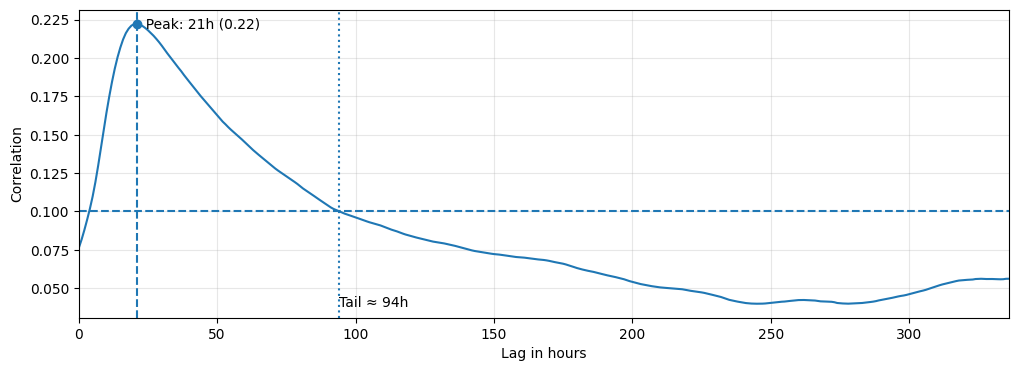

In [ ]:
# Determine peak and tail
peak_lag = int(np.nanargmax(np.abs(crosscorr_values)))
peak_val = crosscorr_values[peak_lag]

relevant_lags = [lag for lag, corr in enumerate(crosscorr_values)
                 if np.isfinite(corr) and abs(corr) >= threshold]
tail_lag = max(relevant_lags) if len(relevant_lags) else None

# Plot 1: Cross-Correlation rain - discharge
lags = np.arange(len(crosscorr_values))

plt.figure(figsize=(12, 4))
plt.plot(lags, crosscorr_values)
plt.axhline(threshold, linestyle="--")

# mark peak
plt.axvline(peak_lag, linestyle="--")
plt.scatter([peak_lag], [peak_val], zorder=3)
plt.text(peak_lag, peak_val, f"  Peak: {peak_lag}h ({peak_val:.2f})", va="center")

# mark tail (last relevant lag)
if tail_lag is not None:
    plt.axvline(tail_lag, linestyle=":")
    plt.text(tail_lag, np.nanmin(crosscorr_values)*0.9, f"Tail ≈ {tail_lag}h", rotation=0, va="bottom")

plt.title("")
plt.xlabel("Lag in hours")
plt.ylabel("Correlation")
plt.xlim(0, max_lag)
plt.grid(True, alpha=0.3)
plt.show()

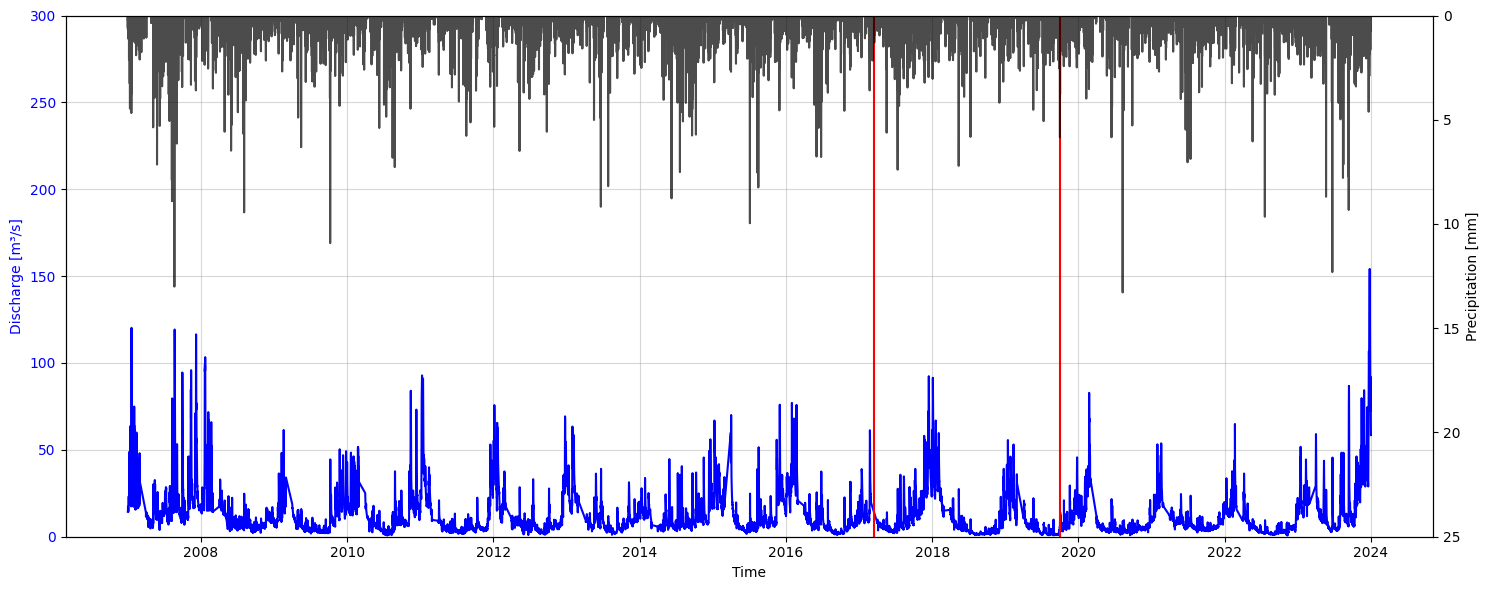

In [ ]:
plt.figure(figsize=(15, 6))

# Plot discharge on the primary y-axis
ax1 = plt.gca() # Get current axes
ax1.plot(data.index, data['discharge'], label='Discharge [m³/s]', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Discharge [m³/s]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Set discharge y-axis limits
ax1.set_ylim(0, 300)

# Create a secondary y-axis for P_weighted
ax2 = ax1.twinx()
ax2.plot(data.index, data['P_weighted'], label='Precipitation [mm]', color='black', alpha=0.7)
ax2.set_ylabel('Precipitation [mm]', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.invert_yaxis() # Invert y-axis to make precipitation 'come from above'

# Set P_weighted y-axis limits (inverted: max value comes first)
ax2.set_ylim(25, 0)

plt.title("")
ax1.grid(True, alpha=0.5)

# Calculate timestamps for the sections
time_start = data.index.min()
time_end = data.index.max()
total_duration = time_end - time_start

time_60_percent = time_start + total_duration * 0.6
time_75_percent = time_start + total_duration * 0.75

# Add vertical lines to delineate sections
ax1.axvline(time_60_percent, color='red', linestyle='-', linewidth=1.5)
ax1.axvline(time_75_percent, color='red', linestyle='-', linewidth=1.5)

plt.tight_layout()
plt.show()

In [ ]:
# Drop 'P_weighted' column if it exists in the DataFrame
if 'P_weighted' in data.columns:
    data = data.drop(columns=['P_weighted'])
    print("Column 'P_weighted' removed from 'data' DataFrame.")
else:
    print("Column 'P_weighted' not found in 'data' DataFrame, nothing to remove.")

# Get the first 4 rows of the DataFrame
head_data = data.head(4)

# Get the last 4 rows of the DataFrame
tail_data = data.tail(4)

# Concatenate them into a single DataFrame for display
sample_data = pd.concat([head_data, tail_data])

display(sample_data)

Column 'P_weighted' removed from 'data' DataFrame.


,augustdorf_2007-2024.csv,bielefeld-mitte_2007-2024.csv,delbrueck-steinhorst_2007-2024.csv,rheda-wiedenbrueck_2007-2024.csv,rietberg_2007-2024.csv,Versmold-Vorbruch_2007-2025.csv,warendorf-freckenhorst_2007-2024.csv,discharge,DOY_sin,DOY_cos
MESS_DATUM,,,,,,,,,,
2007-01-01 00:00:00,0.24,0.2,0.25,0.5,0.00,0.00,0.00,14.45,0.017202,0.999852
2007-01-01 01:00:00,0.03,0.0,0.00,0.0,0.00,0.03,0.00,14.47,0.017202,0.999852
2007-01-01 02:00:00,0.00,0.0,0.00,0.0,0.00,0.13,0.00,14.50,0.017202,0.999852
2007-01-01 03:00:00,0.03,0.2,0.46,0.4,1.97,0.00,1.37,14.52,0.017202,0.999852
2024-01-01 20:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,58.54,0.017202,0.999852
2024-01-01 21:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,58.40,0.017202,0.999852
2024-01-01 22:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,58.40,0.017202,0.999852
2024-01-01 23:00:00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,58.48,0.017202,0.999852


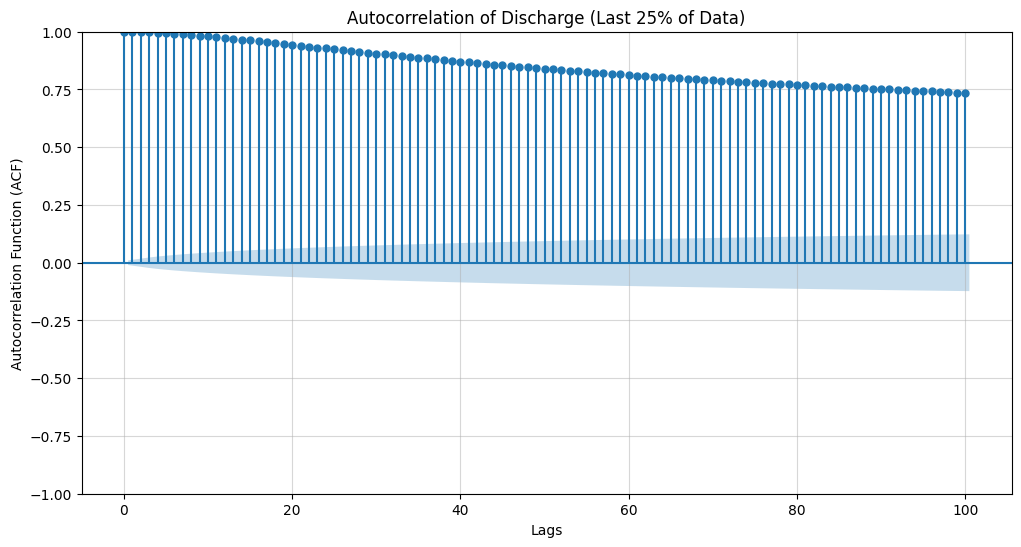

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Calculate the split point for 75% of the data
split_point = int(len(data) * 0.75)

# Slice the 'discharge' data from 75% to 100%
discharge_last_25_percent = data['discharge'].iloc[split_point:]

# Create the autocorrelation plot for 'discharge' from the last 25% of data
plt.figure(figsize=(12, 6))
plot_acf(discharge_last_25_percent, lags=100, ax=plt.gca())
plt.title('Autocorrelation of Discharge (Last 25% of Data)')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation Function (ACF)')
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
# Autocorrelation of the 5 horizons for last 25 % of data
lags = [3, 6, 12, 24, 72]

# Calculate the split point for 75% of the data
split_point = int(len(data) * 0.75)

# Slice the 'discharge' data from 75% to 100%
y = data["discharge"].iloc[split_point:].astype(float)

acf = {}
for h in lags:
    acf[h] = y.autocorr(lag=h)

acf

{3: np.float64(0.9974888575554158),
 6: np.float64(0.9921637144172429),
 12: np.float64(0.9751809882537361),
 24: np.float64(0.9319568607789659),
 72: np.float64(0.8024103035440846)}

In [ ]:
# NSE of persistence model for last 25 % of data

def nse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Avoid division by zero if all true values are the same
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return np.nan # Or a suitable value indicating undefined NSE

    return 1 - np.sum((y_true - y_pred)**2) / denom

# Define the lags to evaluate
lags = [3, 6, 12, 24, 72]

# Calculate the split point for 75% of the data
split_point = int(len(data) * 0.75)

# Get the 'discharge' values for the last 25% of the dataset
y_last_25_percent = data["discharge"].iloc[split_point:].values

print("NSE (Nash-Sutcliffe Efficiency) for Persistence Model (last 25% of data):")
for h in lags:
    # y_true are the observed values at time t+h
    y_true = y_last_25_percent[h:]

    # y_pred are the predicted values from time t (persistence)
    y_pred = y_last_25_percent[:-h]

    # Calculate and print NSE
    nse_value = nse(y_true, y_pred)
    print(f"{h}h: NSE(persistence) = {nse_value:.3f}")

NSE (Nash-Sutcliffe Efficiency) for Persistence Model (last 25% of data):
3h: NSE(persistence) = 0.995
6h: NSE(persistence) = 0.984
12h: NSE(persistence) = 0.950
24h: NSE(persistence) = 0.864
72h: NSE(persistence) = 0.613


In [ ]:
# RMSE of persistence model for last 25 % of data
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

# Define the lags to evaluate
lags = [3, 6, 12, 24, 72]

# Calculate the split point for 75% of the data
split_point = int(len(data) * 0.75)

# Get the 'discharge' values for the last 25% of the dataset
y_last_25_percent = data["discharge"].iloc[split_point:].values

print("RMSE (Root Mean Squared Error) for Persistence Model (last 25% of data):")
for h in lags:
    # y_true are the observed values at time t+h
    y_true = y_last_25_percent[h:]

    # y_pred are the predicted values from time t (persistence)
    y_pred = y_last_25_percent[:-h]

    # Calculate and print RMSE
    rmse_value = rmse(y_true, y_pred)
    print(f"{h}h: RMSE(persistence) = {rmse_value:.3f}")

RMSE (Root Mean Squared Error) for Persistence Model (last 25% of data):
3h: RMSE(persistence) = 0.984
6h: RMSE(persistence) = 1.739
12h: RMSE(persistence) = 3.093
24h: RMSE(persistence) = 5.115
72h: RMSE(persistence) = 8.652


In [ ]:
# NSE of persistence model for the top 5 % quantile of the last 25 % of data

def nse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Avoid division by zero if all true values are the same
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0 or np.isclose(denom, 0):
        return np.nan # Or a suitable value indicating undefined NSE

    return 1 - np.sum((y_true - y_pred)**2) / denom

# Define the lags to evaluate
lags = [3, 6, 12, 24, 72]

# Calculate the split point for 75% of the data
split_point = int(len(data) * 0.75)

# Get the 'discharge' values for the last 25% of the dataset
discharge_series_last_25_percent = data["discharge"].iloc[split_point:]

# Calculate the threshold for the top 5% (95th percentile) from the LAST 25% of the data
quantile_threshold = discharge_series_last_25_percent.quantile(0.95)

# Filter these 'last 25%' discharge values to get only the top 5% quantile within this segment
y_top_5_percent_from_last_25_percent = discharge_series_last_25_percent[discharge_series_last_25_percent >= quantile_threshold].values

# Check if there's enough data for calculation after filtering
if len(y_top_5_percent_from_last_25_percent) == 0:
    print("No discharge values found in the top 5% quantile of the last 25% data.")
elif len(y_top_5_percent_from_last_25_percent) <= max(lags):
    print(f"Not enough data in the top 5% quantile of the last 25% data ({len(y_top_5_percent_from_last_25_percent)} points) to calculate NSE for all lags (max lag: {max(lags)}).")
else:
    print(f"NSE (Nash-Sutcliffe Efficiency) for Persistence Model (top 5% quantile of discharge from last 25% data, threshold: {quantile_threshold:.2f}):")
    for h in lags:
        # y_true are the observed values at time t+h
        y_true = y_top_5_percent_from_last_25_percent[h:]

        # y_pred are the predicted values from time t (persistence)
        y_pred = y_top_5_percent_from_last_25_percent[:-h]

        # Calculate and print NSE
        nse_value = nse(y_true, y_pred)
        print(f"{h}h: NSE(persistence) = {nse_value:.3f}")

NSE (Nash-Sutcliffe Efficiency) for Persistence Model (top 5% quantile of discharge from last 25% data, threshold: 35.27):
3h: NSE(persistence) = 0.987
6h: NSE(persistence) = 0.959
12h: NSE(persistence) = 0.868
24h: NSE(persistence) = 0.654
72h: NSE(persistence) = 0.077


In [ ]:
# RMSE of persistence model for the top 5 % quantile of the last 25 % of data

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

# Define the lags to evaluate
lags = [3, 6, 12, 24, 72]

# Calculate the split point for 75% of the data
split_point = int(len(data) * 0.75)

# Get the 'discharge' values for the last 25% of the dataset
discharge_series_last_25_percent = data["discharge"].iloc[split_point:]

# Calculate the threshold for the top 5% (95th percentile) from the Last 25% of the data
quantile_threshold = discharge_series_last_25_percent.quantile(0.95)

# Filter these 'last 25%' discharge values to get only the top 5% quantile within this segment
y_top_5_percent_from_last_25_percent = discharge_series_last_25_percent[discharge_series_last_25_percent >= quantile_threshold].values

# Check if there's enough data for calculation after filtering
if len(y_top_5_percent_from_last_25_percent) == 0:
    print("No discharge values found in the top 5% quantile of the last 25% data.")
elif len(y_top_5_percent_from_last_25_percent) <= max(lags):
    print(f"Not enough data in the top 5% quantile of the last 25% data ({len(y_top_5_percent_from_last_25_percent)} points) to calculate RMSE for all lags (max lag: {max(lags)}).")
else:
    print(f"RMSE (Root Mean Squared Error) for Persistence Model (top 5% quantile of discharge from last 25% data, threshold: {quantile_threshold:.2f}):")
    for h in lags:
        # y_true are the observed values at time t+h
        y_true = y_top_5_percent_from_last_25_percent[h:]

        # y_pred are the predicted values from time t (persistence)
        y_pred = y_top_5_percent_from_last_25_percent[:-h]

        # Calculate and print RMSE
        rmse_value = rmse(y_true, y_pred)
        print(f"{h}h: RMSE(persistence) = {rmse_value:.3f}")

RMSE (Root Mean Squared Error) for Persistence Model (top 5% quantile of discharge from last 25% data, threshold: 35.27):
3h: RMSE(persistence) = 2.871
6h: RMSE(persistence) = 5.224
12h: RMSE(persistence) = 9.334
24h: RMSE(persistence) = 15.158
72h: RMSE(persistence) = 24.886


In [ ]:
# Define the base directory for saving the file

# Define the filename
output_filename = "Einen_Ems_Precipitation_Discharge_DOY.csv"
output_path = base_dir / output_filename

# Save the DataFrame to CSV
data.to_csv(output_path, index=True, sep=";")

print(f"DataFrame successfully saved to: {output_path}")

DataFrame successfully saved to: /content/drive/MyDrive/Haberstock_ML_Data/Input_Data_Stations/Einen_Ems_Precipitation_Discharge_DOY.csv
